In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

<bold>Business Understanding</bold>
<li>Tujuan : Membantu perusahaan pelayaran atau pihak terkait memahami faktor-foktor yang mempengaruhi keselamatan penumpang, serta memprediksi kemungkinan keselamatan penumpang berdasarkan karakteristik tertentu.</li>
<li>Manfaat :
<br>
<ol>memberikan insight untuk perbaikan sistem keselmatan di masa depan
</ol>
<ol>menggunakan model ML untuk memprediksi kemungkinan keselamatan penumpang
</ol>

In [15]:
df = pd.read_csv('../../Data/titanic_cleaned.csv')
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,892,0,3,0,34.5,0,0,7.8292,2
1,893,1,3,1,47.0,1,0,7.0000,0
2,894,0,2,0,62.0,0,0,9.6875,2
3,895,0,3,0,27.0,0,0,8.6625,0
4,896,1,3,1,22.0,1,1,12.2875,0


# Preprocessing Data

In [16]:
# Split data
X = df.drop('Survived', axis=1)
y = df['Survived']

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Transformasi data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
X_train.shape

(334, 8)

In [18]:
X_test.shape[1]

8

### Membangun arsitektur hidden layer

In [ ]:
# Modelling 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

# Hiden Layer 1 16 neuron
model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))

# Hiden Layer 2 8 neuron
model.add(Dense(8, activation='relu'))

# Output Layer 1 neuron, aktivasi sigmoid untuk klasifikasi biner
model.add(Dense(1, activation='sigmoid'))

model.summary()


c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Kompilasi Model 
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Training Model neural network
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
    )

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6255 - loss: 0.7657 - val_accuracy: 0.6716 - val_loss: 0.6912
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6404 - loss: 0.6910 - val_accuracy: 0.6716 - val_loss: 0.6891
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6404 - loss: 0.6888 - val_accuracy: 0.6716 - val_loss: 0.6859
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6404 - loss: 0.6863 - val_accuracy: 0.6716 - val_loss: 0.6827
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6404 - loss: 0.6836 - val_accuracy: 0.6716 - val_loss: 0.6796
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6404 - loss: 0.6812 - val_accuracy: 0.6716 - val_loss: 0.6766
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6404 - loss: 0.6791 - val_accuracy: 0.6716 - val_loss: 0.6739
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6404 - loss: 0.6771 - val_accuracy: 0.6716 - val_loss: 0.6714


In [23]:
# Evaluasi Model (testing data)

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f'Test Loss: {loss:.2f}')
print(f'Test Accuracy: {accuracy:.2f}')

Test Loss: 0.68
Test Accuracy: 0.60


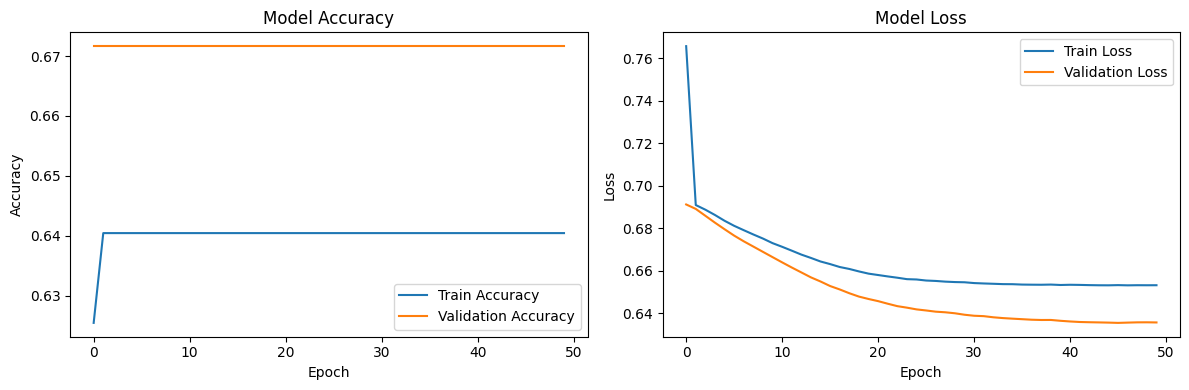

In [24]:
# Visualisasi Accuracy dan Loss

plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()